In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")  # Grayscale
            img = img.resize((img_width, img_height))  # Resize to 28x28
            img = np.array(img) / 255.0  # Normalize to [0,1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load train and test data
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print shapes
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (17002, 28, 28, 1), Labels: (17002, 10)
Testing set: (3001, 28, 28, 1), Labels: (3001, 10)


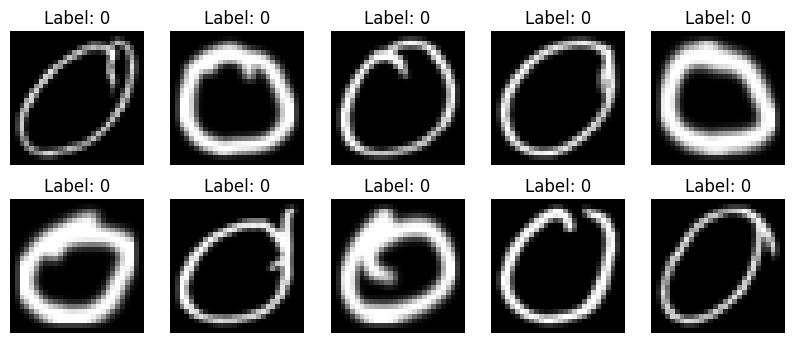

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
batch_size = 128
epochs = 20

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.h5",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2971 - loss: 1.9636

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4950 - loss: 1.5826 - val_accuracy: 2.9403e-04 - val_loss: 7.5218
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8518 - loss: 0.5015 - val_accuracy: 2.9403e-04 - val_loss: 9.0801
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9180 - loss: 0.2784 - val_accuracy: 2.9403e-04 - val_loss: 9.6545
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9390 - loss: 0.2033 - val_accuracy: 2.9403e-04 - val_loss: 10.0941
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9545 - loss: 0.1549 - val_accuracy: 2.9403e-04 - val_loss: 10.3731


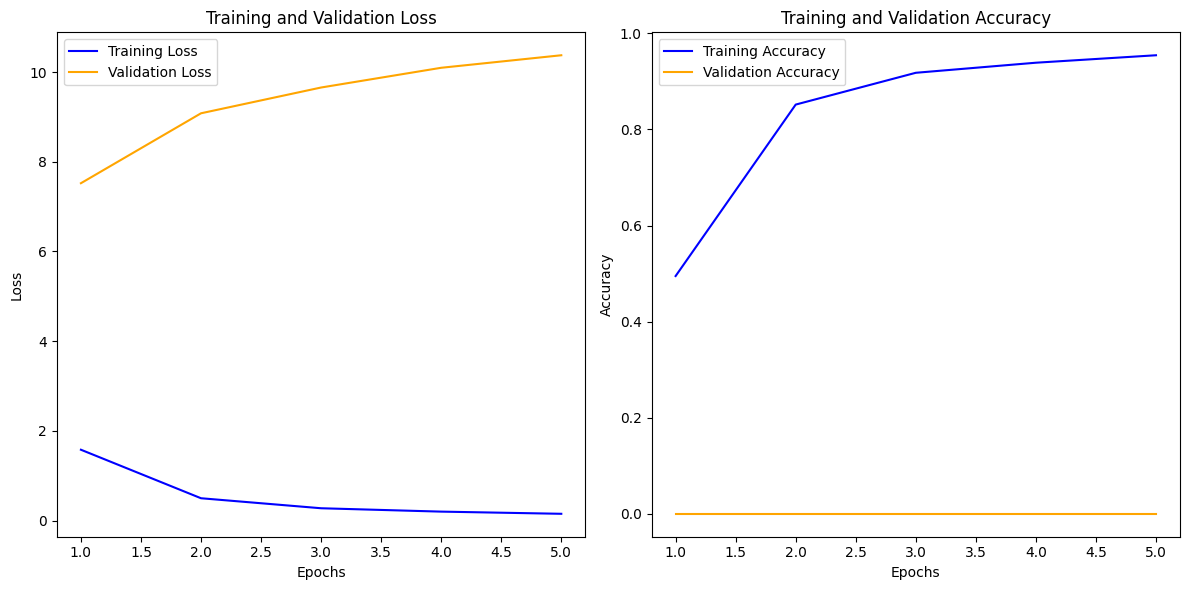

In [8]:
# Extract history values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss,
         label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss,
         label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc,
         label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc,
         label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7594 - loss: 2.2039
Test Loss: 2.2039
Test Accuracy: 0.7594


In [10]:
# Save the model
model.save('devnagari_fcn_model.h5')
print("Model saved!")

# Load the model
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded!")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

Model saved!
Model loaded!
94/94 - 1s - 6ms/step - accuracy: 0.7594 - loss: 2.2039
Loaded Model Test Accuracy: 0.7594


In [11]:
predictions = loaded_model.predict(x_test)

# Convert probabilities to labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Print first 5 results
for i in range(5):
    print(f"Predicted: {predicted_labels[i]}, Actual: {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
